In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, hour, month, dayofweek, when

spark = SparkSession.builder.getOrCreate()

spark.sql("USE CATALOG workspace")
spark.sql("USE SCHEMA crime_data")

crime_df = spark.table("crime_parquet_table")

crime_df = crime_df.withColumn(
    "Date",
    to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a")
)

crime_df = crime_df \
    .withColumn("Hour", hour(col("Date"))) \
    .withColumn("Month", month(col("Date"))) \
    .withColumn("DayOfWeek", dayofweek(col("Date"))) \
    .withColumn("IsWeekend", (dayofweek(col("Date")).isin([1,7])).cast("integer")) \
    .withColumn("label", when(col("Arrest") == True, 1).otherwise(0))

selected_columns = [
    "Year","Month","Hour","DayOfWeek",
    "District","Beat","Community_Area",
    "Primary_Type","Domestic","IsWeekend","label"
]

crime_ml_df = crime_df.select(selected_columns).dropna()

train_df = crime_ml_df.filter(col("Year") < 2021)
test_df  = crime_ml_df.filter(col("Year") >= 2022)

In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, DecisionTreeClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

primary_indexer = StringIndexer(inputCol="Primary_Type", outputCol="Primary_Type_index", handleInvalid="keep")
primary_encoder = OneHotEncoder(inputCol="Primary_Type_index", outputCol="Primary_Type_vec")

assembler = VectorAssembler(
    inputCols=[
        "Year","Month","Hour","DayOfWeek",
        "District","Beat","Community_Area",
        "Domestic","IsWeekend","Primary_Type_vec"
    ],
    outputCol="features",
    handleInvalid="keep"
)

evaluator = BinaryClassificationEvaluator(labelCol="label")

In [0]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)

pipeline_lr = Pipeline(stages=[primary_indexer, primary_encoder, assembler, lr])
lr_model = pipeline_lr.fit(train_df)
predictions_lr = lr_model.transform(test_df)

auc_lr = evaluator.evaluate(predictions_lr)
print("Logistic Regression AUC:", auc_lr)

Logistic Regression AUC: 0.7819629547631001


In [0]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxDepth=10)

pipeline_rf = Pipeline(stages=[primary_indexer, primary_encoder, assembler, rf])
rf_model = pipeline_rf.fit(train_df)
predictions_rf = rf_model.transform(test_df)

auc_rf = evaluator.evaluate(predictions_rf)
print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.7817745823567931


In [0]:
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=10)

pipeline_dt = Pipeline(stages=[primary_indexer, primary_encoder, assembler, dt])
dt_model = pipeline_dt.fit(train_df)
predictions_dt = dt_model.transform(test_df)

auc_dt = evaluator.evaluate(predictions_dt)
print("Decision Tree AUC:", auc_dt)

Decision Tree AUC: 0.2653183136704874


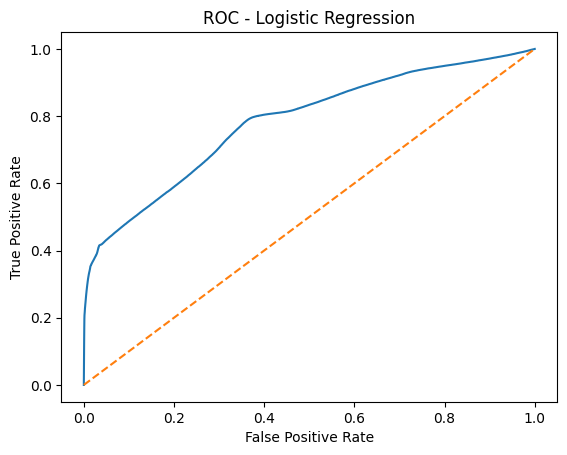

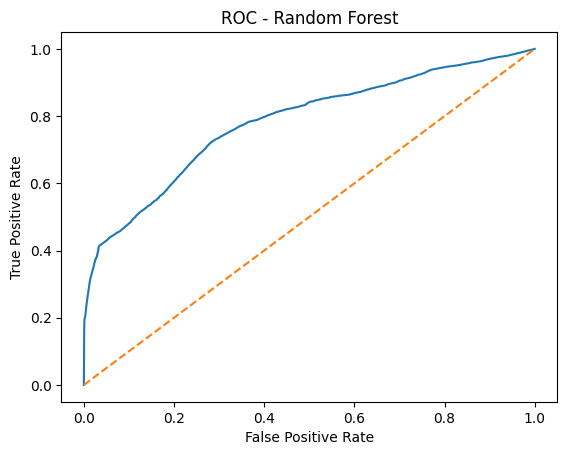

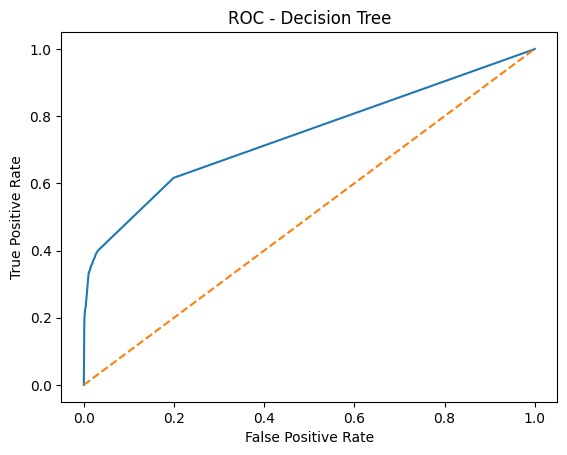

In [0]:
import matplotlib.pyplot as plt
from pyspark.ml.functions import vector_to_array

def plot_roc(predictions, title):
    probs = predictions.withColumn("prob_array", vector_to_array(col("probability")))
    pdf = probs.select(col("label"), col("prob_array")[1].alias("prob")).toPandas()

    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(pdf["label"], pdf["prob"])

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

plot_roc(predictions_lr, "ROC - Logistic Regression")
plot_roc(predictions_rf, "ROC - Random Forest")
plot_roc(predictions_dt, "ROC - Decision Tree")

Gradient Boosting AUC: 0.8445554313481727


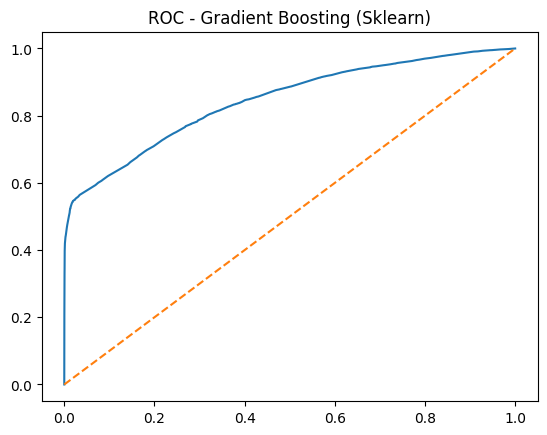

In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve

sample_df = crime_ml_df.sample(fraction=0.05, seed=42).toPandas()

X = sample_df.drop("label", axis=1)
y = sample_df["label"]

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_prob = gb.predict_proba(X_test)[:,1]
auc_sklearn = roc_auc_score(y_test, y_prob)

print("Gradient Boosting AUC:", auc_sklearn)

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr_gb, tpr_gb)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC - Gradient Boosting (Sklearn)")
plt.show()

In [0]:
print("Final Model Comparison")
print("----------------------")
print("Logistic Regression:", auc_lr)
print("Random Forest:", auc_rf)
print("Decision Tree:", auc_dt)
print("Gradient Boosting (Sklearn):", auc_sklearn)

Final Model Comparison
----------------------
Logistic Regression: 0.7819629547631001
Random Forest: 0.7817745823567931
Decision Tree: 0.2653183136704874
Gradient Boosting (Sklearn): 0.8445554330792137


In [0]:
from pyspark.sql.functions import col

# Use Random Forest predictions
cm_df = predictions_rf.groupBy("label", "prediction").count()

cm_df.show()

+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    1|       0.0| 85566|
|    1|       1.0| 52527|
|    0|       0.0|861537|
|    0|       1.0| 25324|
+-----+----------+------+



In [0]:
cm_labeled = predictions_rf \
    .withColumn("Actual", 
        when(col("label") == 1, "Positive").otherwise("Negative")) \
    .withColumn("Predicted", 
        when(col("prediction") == 1, "Positive").otherwise("Negative")) \
    .groupBy("Actual", "Predicted").count()

cm_labeled.show()

+--------+---------+------+
|  Actual|Predicted| count|
+--------+---------+------+
|Positive| Negative| 85566|
|Positive| Positive| 52527|
|Negative| Negative|861537|
|Negative| Positive| 25324|
+--------+---------+------+



In [0]:
best_rf = rf_model.stages[-1]
importances = best_rf.featureImportances

print(importances)

(42,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,25,26,27,28,30,35,36],[0.005338466435953712,4.536890927600528e-05,0.007941393833647408,9.651881702209818e-06,0.0011576064170255795,0.0005241368309811133,0.00228318571891944,0.009919989863561816,7.111093254856432e-06,0.0606961213364549,0.0036064923793805693,0.0318770139851779,0.604719175348372,0.0012990981492105225,0.003410485411090987,0.02460645680520018,0.008951862808737714,0.0043595886064227984,0.007253537980977188,0.08065618107741386,0.03363745050029549,0.07364271163823133,1.6751624469837534e-06,0.009320626370530258,1.423678843422514e-05,0.012446285212407886,0.00648211831740709,0.005367871034830867,0.0003404013042862308,3.070770545640888e-06,8.062802782314882e-05])


In [0]:
from pyspark.ml import PipelineModel

loaded_model = PipelineModel.load(
    "/Volumes/workspace/crime_data/ml_models/best_rf_model"
)

print("Model loaded successfully.")

Model loaded successfully.


In [0]:
import pickle

with open("sklearn_model.pkl", "wb") as f:
    pickle.dump(gb, f)